In [ ]:
import pandas as pd

# Load CSV
df = pd.read_excel("DATA_1.xlsx")

print(df.head())
print(df.columns)

  Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  \
0      CHEMBL4076855           NaN                 NaN            511.09   
1      CHEMBL4066837           NaN                 NaN            511.09   
2      CHEMBL1163400           NaN                 NaN            596.75   
3      CHEMBL1165393           NaN                 NaN            610.78   
4      CHEMBL1163407           NaN                 NaN            658.82   

   #RO5 Violations  AlogP Compound Key  \
0              0.0   2.15           5a   
1              0.0   2.15           5b   
2              1.0   2.53          10a   
3              1.0   2.92          10b   
4              1.0   3.68          10e   

                                              Smiles Standard Type  \
0  CC[C@H](C)Nc1cc(C(=O)N[C@@H](Cc2ccccc2)[C@H](O...          IC50   
1  CC[C@H](C)Nc1cc(C(=O)N[C@@H](Cc2ccccc2)[C@H](O...          IC50   
2  CC1=C(C(=O)NOCc2ccccc2)C(C)C(C(=O)N[C@@H](Cc2c...          IC50   
3  CCC1C(C

In [ ]:
print(df['Standard Type'].unique())
print(df['Standard Units'].unique())
print(df['Standard Relation'].unique())

['IC50']
['nM']
["'>'" "'='" "'<'"]


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("DATA_1.xlsx")

# Clean formatting
for col in ['Standard Type','Standard Units','Standard Relation']:
    df[col] = df[col].astype(str).str.strip().str.replace("'", "")

# Filter
df = df[df['Standard Type'] == 'IC50']
df = df[df['Standard Units'] == 'nM']
df = df[df['Standard Relation'] == '=']

# Keep needed columns
df = df[['Molecule ChEMBL ID','Smiles','Standard Value']]

# Remove duplicates
df = df.drop_duplicates(subset='Smiles')

# Convert to pIC50
df['pIC50'] = -np.log10(df['Standard Value']*1e-9)

print(df.head())
print(df.shape)

  Molecule ChEMBL ID                                             Smiles  \
1      CHEMBL4066837  CC[C@H](C)Nc1cc(C(=O)N[C@@H](Cc2ccccc2)[C@H](O...   
2      CHEMBL1163400  CC1=C(C(=O)NOCc2ccccc2)C(C)C(C(=O)N[C@@H](Cc2c...   
3      CHEMBL1165393  CCC1C(C(=O)NOCc2ccccc2)=C(C)N(S(C)(=O)=O)C(C)=...   
4      CHEMBL1163407  CC1=C(C(=O)NOCc2ccccc2)C(c2ccccc2)C(C(=O)N[C@@...   
5      CHEMBL1165492  CC1=C(C(=O)OCc2ccccc2)C(C)C(C(=O)N[C@@H](Cc2cc...   

   Standard Value     pIC50  
1             5.0  8.301030  
2         14900.0  4.826814  
3          9500.0  5.022276  
4         21400.0  4.669586  
5         16100.0  4.793174  
(8253, 4)


In [ ]:
df.to_excel("Processed_DATA_1.xlsx", index=False)

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 45.7 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return np.array(fp)
    else:
        return None

# Generate fingerprints
df['Fingerprint'] = df['Smiles'].apply(smiles_to_fp)

# Remove invalid molecules
df = df[df['Fingerprint'].notnull()]

Streaming output truncated to the last 5000 lines.
[15:38:23] DEPRECATION WARNING: please use MorganGenerator
[15:38:23] DEPRECATION WARNING: please use MorganGenerator
[15:38:23] DEPRECATION WARNING: please use MorganGenerator
[15:38:23] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:38:24] DEPRECATION WARNING: please use MorganGenerator
[15:3

In [ ]:
X_fp = np.array(df['Fingerprint'].tolist())
y = df['pIC50'].values

print(X_fp.shape)
print(y.shape)

(8253, 2048)
(8253,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(
    X_fp, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_fp, y_train_fp)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_fp)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_r2 = r2_score(y_test_fp, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_fp, y_pred_rf))
rf_mae = mean_absolute_error(y_test_fp, y_pred_rf)

print("RF R²:", rf_r2)
print("RF RMSE:", rf_rmse)
print("RF MAE:", rf_mae)

RF R²: 0.6256337804971109
RF RMSE: 0.7913156642841516
RF MAE: 0.5820947045396956


In [ ]:
predictions = rf_model.predict(X_fp)
df['Predicted_pIC50'] = predictions

In [ ]:
top_hits = df.sort_values(by='Predicted_pIC50', ascending=False).head(10)
print(top_hits[['Molecule ChEMBL ID','Smiles','Predicted_pIC50']])

      Molecule ChEMBL ID                                             Smiles  \
2515       CHEMBL3969403  CC1(C)C(N)=N[C@](C)(c2cc(NC(=O)c3ccc(C#N)cn3)c...   
14075      CHEMBL3949213  C[C@@]1(c2cc(NC(=O)c3ccc(C#N)cn3)ccc2F)CS(=O)(...   
6559       CHEMBL3261078  CC1(C)C(N)=N[C@](C)(c2cc(NC(=O)c3ccc(Cl)cn3)cc...   
14074      CHEMBL3955051  CC1(C)C(N)=N[C@](C)(c2cc(NC(=O)c3cnc(C(F)F)cn3...   
6560       CHEMBL3937515  COc1cnc(C(=O)Nc2ccc(F)c([C@]3(C)CS(=O)(=O)C(C)...   
14073      CHEMBL3930841  C[C@@]1(c2cc(NC(=O)c3ccc(C#N)cn3)ccc2F)CS(=O)(...   
1914       CHEMBL3936264  C[C@@]1(c2cc(NC(=O)c3ccc(OC(F)F)cn3)ccc2F)CS(=...   
2514       CHEMBL3958332  C[C@@]1(c2cc(NC(=O)c3ccc(Cl)cn3)ccc2F)CS(=O)(=...   
12580      CHEMBL5979230  C[C@@]1(c2cc(NC(=O)c3ccc(Cl)cn3)ccc2F)CS(=O)(=...   
13412      CHEMBL5847284  CC#CCOc1ccc(C(=O)Nc2ccc(F)c([C@]3(C)CS(=O)(=O)...   

       Predicted_pIC50  
2515         11.613158  
14075        11.193768  
6559         11.050739  
14074        10.889434  
6560 

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

smiles = top_hits.iloc[0]['Smiles']
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol)
AllChem.MMFFOptimizeMolecule(mol)

Chem.MolToMolFile(mol, "compound1.mol")

Tokenize Smiles


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

smiles = df['Smiles'].tolist()

tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(smiles)

sequences = tokenizer.texts_to_sequences(smiles)

X = pad_sequences(sequences, maxlen=500, padding='post')
y = df['pIC50'].values

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=128
    ),

    Bidirectional(LSTM(128, return_sequences=True)),

    Dropout(0.3),

    Bidirectional(LSTM(64)),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - loss: 2.1050 - mae: 1.1684 - val_loss: 1.6796 - val_mae: 1.0489
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - loss: 2.1382 - mae: 1.1825 - val_loss: 1.8113 - val_mae: 1.0990
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - loss: 2.1530 - mae: 1.1826 - val_loss: 1.6566 - val_mae: 1.0492
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 2.0915 - mae: 1.1714 - val_loss: 1.6831 - val_mae: 1.0535
Epoch 5/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 1.9673 - mae: 1.1349 - val_loss: 1.5012 - val_mae: 0.9786
Epoch 6/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 1.8946 - mae: 1.0970 - val_loss: 1.4808 - val_mae: 0.9596
Epoch 7/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 1.7753 - mae: 1.0615 - val_loss: 1.2916 - val_mae: 0.9040
Epoch 8/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 1.6841 - mae: 1.0379 - val_loss: 1.3017 - val_mae: 0.9057
Epoch 9/50
166/166 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test)

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.4713464808243447
RMSE: 0.9403445236753188
MAE: 0.7269488780683723


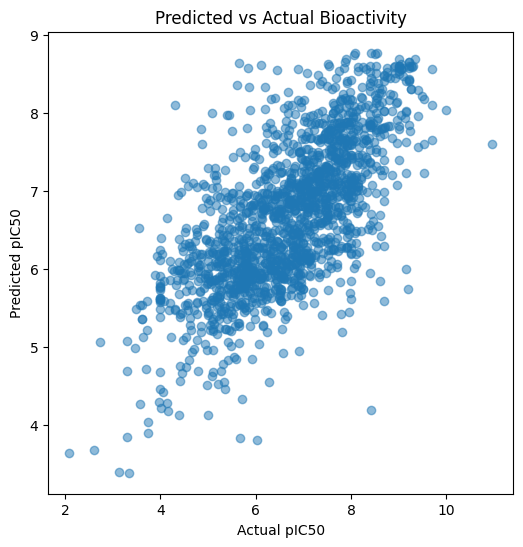

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs Actual Bioactivity")
plt.show()

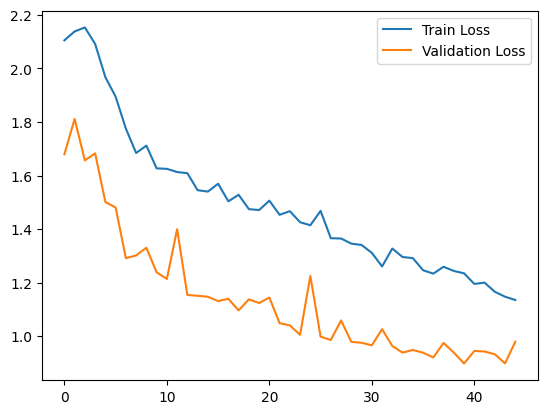

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
print(X.shape)
print(y.shape)
print(max(len(s) for s in smiles))

(8253, 500)
(8253,)
458


**DNN**

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "LSTM", "Descriptor DNN"],

    "R2 Score": [
        r2_score(y_test_fp, y_pred_rf),
        r2_score(y_test, y_pred),
        r2_score(y_test_fp, y_pred_dnn)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test_fp, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test_fp, y_pred_dnn))
    ],

    "MAE": [
        mean_absolute_error(y_test_fp, y_pred_rf),
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test_fp, y_pred_dnn)
    ]
})

results

,Model,R2 Score,RMSE,MAE
0,Random Forest,0.625634,0.791316,0.582095
1,LSTM,0.471346,0.940345,0.726949
2,Descriptor DNN,0.611075,0.806555,0.594096


In [ ]:
from rdkit.Chem import Descriptors
import numpy as np

def calc_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.HeavyAtomCount(mol)
    ]

desc_features = np.array([calc_rdkit_descriptors(s) for s in df['Smiles']])

In [ ]:
X_combined = np.concatenate([X_fp, desc_features], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_dnn, X_test_dnn, y_train_dnn, y_test_dnn = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_dnn = scaler.fit_transform(X_train_dnn)
X_test_dnn = scaler.transform(X_test_dnn)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

dnn_model = Sequential([

    Dense(1024, activation='relu', input_shape=(2056,)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.10),

    Dense(1)
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7
)

history_dnn = dnn_model.fit(
    X_train_dnn,
    y_train_dnn,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 42.0247 - mae: 6.2895 - val_loss: 36.9695 - val_mae: 5.9839 - learning_rate: 3.0000e-04
Epoch 2/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 30.6003 - mae: 5.3485 - val_loss: 23.1431 - val_mae: 4.6712 - learning_rate: 3.0000e-04
Epoch 3/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 16.9314 - mae: 3.8373 - val_loss: 9.6187 - val_mae: 2.8486 - learning_rate: 3.0000e-04
Epoch 4/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 7.0187 - mae: 2.2631 - val_loss: 3.1385 - val_mae: 1.4911 - learning_rate: 3.0000e-04
Epoch 5/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 3.2109 - mae: 1.4305 - val_loss: 1.5291 - val_mae: 0.9754 - learning_rate: 3.0000e-04
Epoch 6/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 2.4558 - mae: 1.2370 - val_loss: 1.2683 - val_mae: 0.8666 - learning_rate: 3.0000e-04
Epoch 7/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 2.0169 - mae: 1.1159 - val_loss: 1.0797 - 

In [ ]:
y_pred_dnn = dnn_model.predict(X_test_dnn).flatten()

print("===== SUPER DNN RESULTS =====")
print("R² Score :", r2_score(y_test_dnn, y_pred_dnn))
print("RMSE     :", np.sqrt(mean_squared_error(y_test_dnn, y_pred_dnn)))
print("MAE      :", mean_absolute_error(y_test_dnn, y_pred_dnn))

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
===== SUPER DNN RESULTS =====
R² Score : 0.6063264587762471
RMSE     : 0.8114645453712643
MAE      : 0.6021880336693682


In [ ]:
from scipy.stats import pearsonr
import pandas as pd

# Pearson correlations
rf_pearson, rf_p = pearsonr(y_test_fp, y_pred_rf)
lstm_pearson, lstm_p = pearsonr(y_test, y_pred.flatten())
dnn_pearson, dnn_p = pearsonr(y_test_fp, y_pred_dnn)

# Create summary table
pearson_df = pd.DataFrame({
    "Model": ["Random Forest", "LSTM", "Descriptor DNN"],
    "Pearson r": [rf_pearson, lstm_pearson, dnn_pearson],
    "P-value": [rf_p, lstm_p, dnn_p]
})

print(pearson_df)

NameError: name 'y_pred_rf' is not defined

In [ ]:
prediction_df = pd.DataFrame({
    'Actual': y_test_dnn,
    'Predicted_DNN': y_pred_dnn
})

print(prediction_df)

        Actual  Predicted_DNN
0     6.102373       4.713785
1     9.204815       9.876912
2     6.236572       5.155773
3     5.743282       6.309298
4     4.524329       6.685912
...        ...            ...
1646  7.328827       7.004029
1647  5.649752       5.683988
1648  4.863279       6.183152
1649  8.301030       7.191875
1650  7.253366       6.647931

[1651 rows x 2 columns]


In [ ]:
prediction_df.to_csv("DNN_Test_Predictions.csv", index=False)

In [ ]:
top20_hits = prediction_df.sort_values(
    by='Predicted_DNN',
    ascending=False
).head(20)

In [ ]:
print(top20_hits)

        CHEMBL ID    Actual  Predicted_DNN
1   CHEMBL5184180  5.986741      63.303886
2    CHEMBL406089  4.397940      47.853836
3    CHEMBL265158  4.346787      47.464512
4   CHEMBL2370074  4.397940      39.170490
5   CHEMBL2370886  7.522879      38.822647
6   CHEMBL5184970  5.870310      27.114948
7    CHEMBL134730  6.853872      25.768000
8    CHEMBL311262  7.309804      25.726929
9   CHEMBL5179569  6.747147      25.702095
10   CHEMBL242315  7.920819      25.521149
11   CHEMBL538647  7.920819      25.521149
12   CHEMBL510512  4.694004      25.502071
13   CHEMBL450745  5.508638      25.502071
14  CHEMBL2181021  5.265200      24.806942
15   CHEMBL434943  7.795880      24.674355
16  CHEMBL1927636  6.783834      24.665253
17  CHEMBL1927635  7.341989      24.373209
18    CHEMBL89703  4.823909      24.345551
19    CHEMBL89530  6.301030      24.123276
20   CHEMBL183059  7.075721      24.073870


In [ ]:
from sklearn.model_selection import train_test_split

X = X_combined # Use the already prepared combined features
y = df['pIC50']
chembl_ids = df['Molecule ChEMBL ID'] # Correct column name for ChEMBL IDs

X_train_dnn, X_test_dnn, y_train_dnn, y_test_dnn, id_train_dnn, id_test_dnn = train_test_split(
    X,
    y,
    chembl_ids,
    test_size=0.2,
    random_state=42
)

In [ ]:
y_pred_dnn = dnn_model.predict(X_test_dnn)

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
prediction_df = pd.DataFrame({
    'CHEMBL ID': id_test_dnn.values,
    'Actual': y_test_dnn.values,
    'Predicted_DNN': y_pred_dnn.flatten()
})

In [ ]:
prediction_df.to_csv("DNN_Test_Predictions.csv", index=False)

In [ ]:
top_hits = prediction_df.sort_values(
    by='Predicted_DNN',
    ascending=False
).head(30)

top_hits = top_hits.reset_index(drop=True)
top_hits.index += 1

print(top_hits)

        CHEMBL ID    Actual  Predicted_DNN
1   CHEMBL5184180  5.986741      63.303886
2    CHEMBL406089  4.397940      47.853836
3    CHEMBL265158  4.346787      47.464512
4   CHEMBL2370074  4.397940      39.170490
5   CHEMBL2370886  7.522879      38.822647
6   CHEMBL5184970  5.870310      27.114948
7    CHEMBL134730  6.853872      25.768000
8    CHEMBL311262  7.309804      25.726929
9   CHEMBL5179569  6.747147      25.702095
10   CHEMBL242315  7.920819      25.521149
11   CHEMBL538647  7.920819      25.521149
12   CHEMBL510512  4.694004      25.502071
13   CHEMBL450745  5.508638      25.502071
14  CHEMBL2181021  5.265200      24.806942
15   CHEMBL434943  7.795880      24.674355
16  CHEMBL1927636  6.783834      24.665253
17  CHEMBL1927635  7.341989      24.373209
18    CHEMBL89703  4.823909      24.345551
19    CHEMBL89530  6.301030      24.123276
20   CHEMBL183059  7.075721      24.073870
21  CHEMBL2019055  8.698970      23.662704
22  CHEMBL2181020  6.779892      23.652803
23   CHEMBL

In [ ]:
df_final = pd.read_excel("/content/DNN_Test_Predictions_final.xlsx")

In [ ]:
df_final

,Actual,Predicted_DNN,CHEMBL ID
0,6.102373,4.713785,CHEMBL2380444
1,9.204815,9.876912,CHEMBL5286535
2,6.236572,5.155773,CHEMBL3261059
3,5.743282,6.309298,CHEMBL5430322
4,4.524329,6.685912,CHEMBL1096682
...,...,...,...
1646,7.328827,7.004029,CHEMBL3688643
1647,5.649752,5.683988,CHEMBL3650803
1648,4.863279,6.183152,CHEMBL3951840
1649,8.301030,7.191875,CHEMBL373533


In [ ]:
df_final.sort_values(by='Predicted_DNN', ascending=False).head(30)

,Actual,Predicted_DNN,CHEMBL ID
1,9.204815,9.876912,CHEMBL5286535
1427,8.040959,9.246370,CHEMBL4868952
1182,9.221849,9.235050,CHEMBL3949245
228,9.045757,9.174429,CHEMBL3922952
522,9.221849,9.122324,CHEMBL3945386
378,9.154902,9.073134,CHEMBL2031143
839,7.754487,9.044613,CHEMBL4564324
589,8.397940,9.038609,CHEMBL6009843
1305,8.585027,9.007524,CHEMBL3893104
1556,9.131356,8.951748,CHEMBL3667413


In [ ]:
DF_top30=df_final.sort_values(by='Predicted_DNN', ascending=False).head(30)

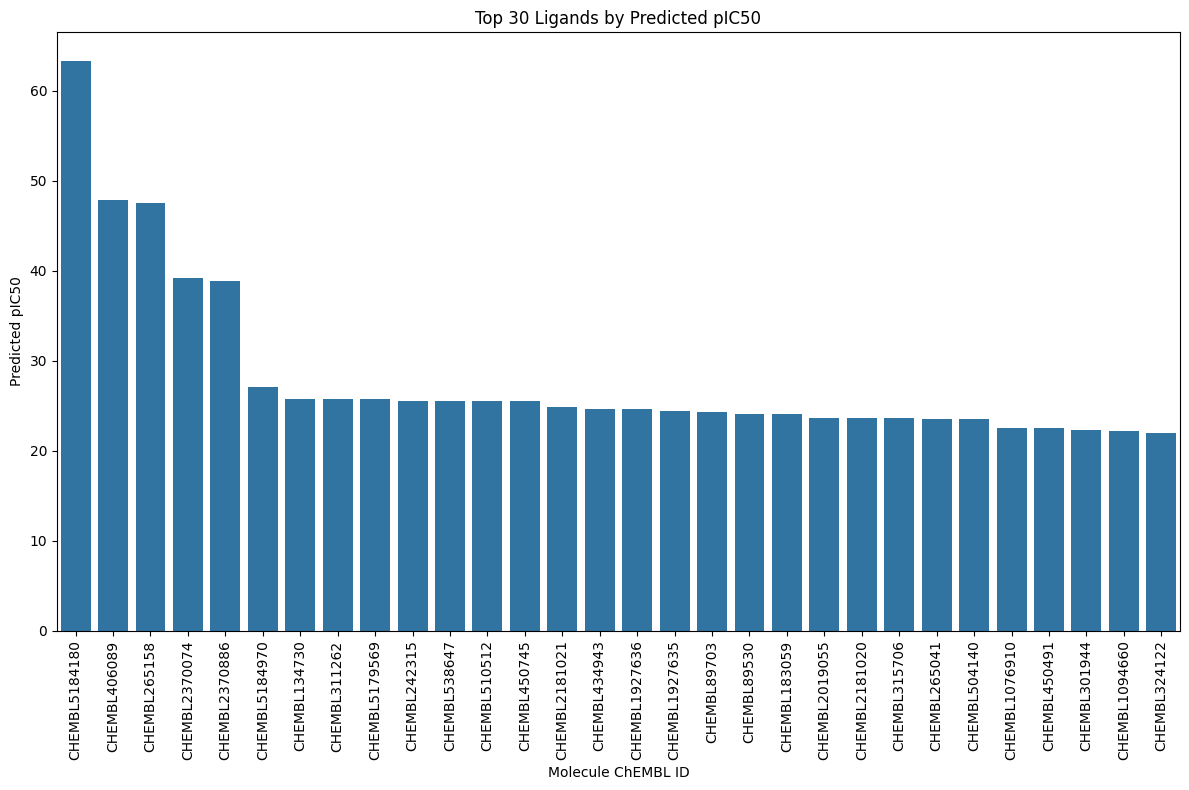

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='CHEMBL ID', y='Predicted_DNN', data=top_hits)
plt.xlabel('Molecule ChEMBL ID')
plt.ylabel('Predicted pIC50')
plt.title('Top 30 Ligands by Predicted pIC50')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

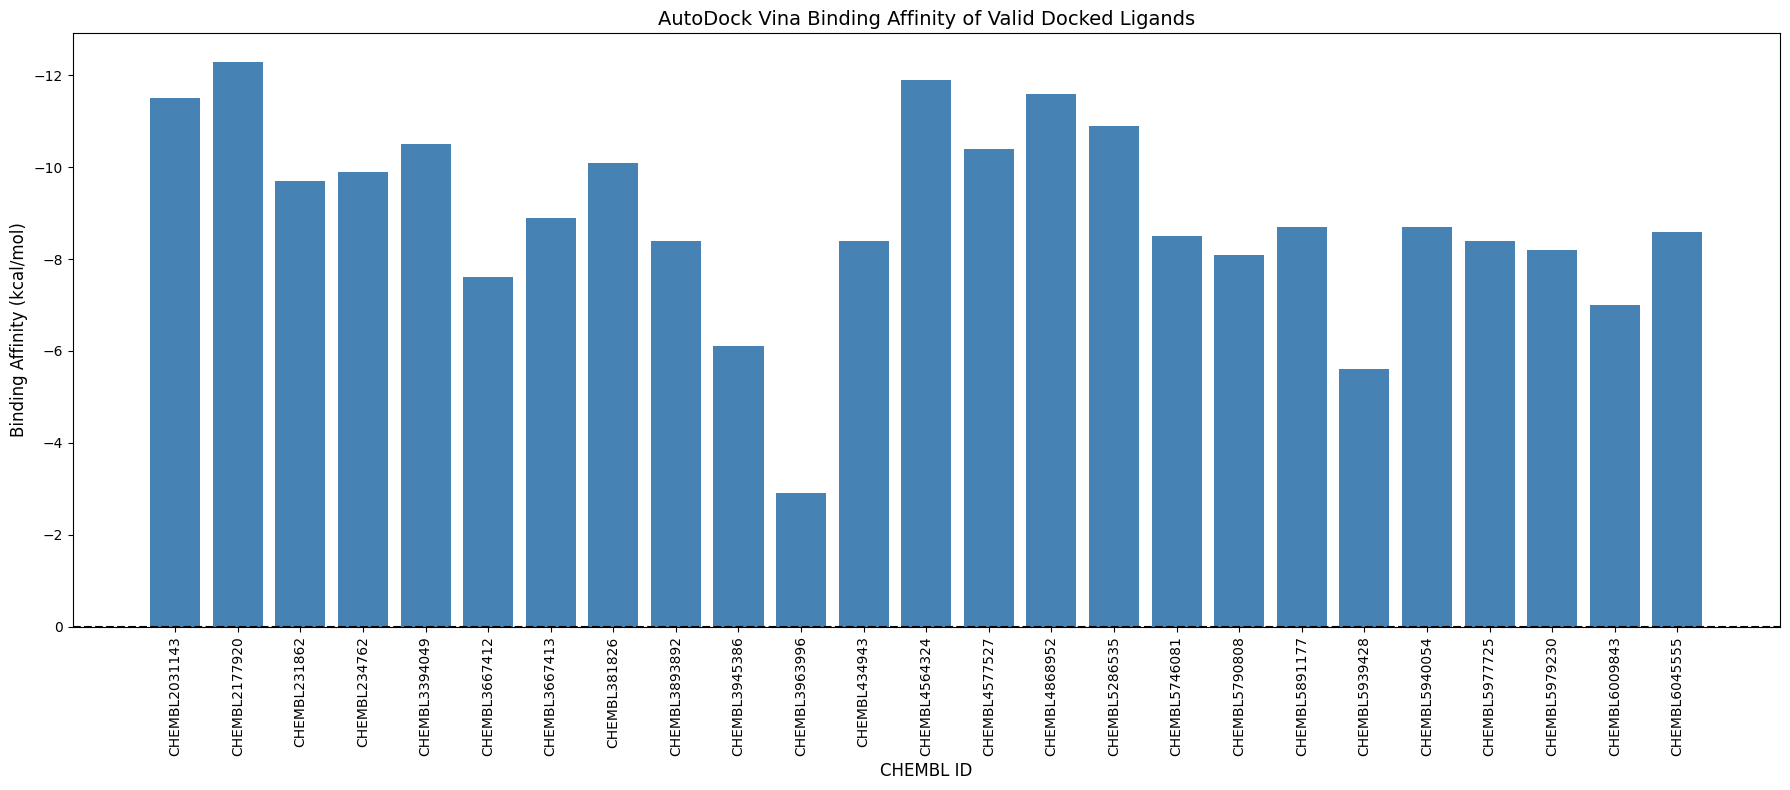

In [ ]:
import matplotlib.pyplot as plt

# Only ligands with valid negative docking affinity
chembl_ids = [
    "CHEMBL2031143","CHEMBL2177920","CHEMBL231862","CHEMBL234762","CHEMBL3394049",
    "CHEMBL3667412","CHEMBL3667413","CHEMBL381826","CHEMBL3893892",
    "CHEMBL3945386","CHEMBL3963996","CHEMBL434943","CHEMBL4564324",
    "CHEMBL4577527","CHEMBL4868952","CHEMBL5286535","CHEMBL5746081",
    "CHEMBL5790808","CHEMBL5891177","CHEMBL5939428","CHEMBL5940054",
    "CHEMBL5977725","CHEMBL5979230","CHEMBL6009843","CHEMBL6045555"
]

affinity = [
    -11.5,-12.3,-9.7,-9.9,-10.5,
    -7.6,-8.9,-10.1,-8.4,
    -6.1,-2.9,-8.4,-11.9,
    -10.4,-11.6,-10.9,-8.5,
    -8.1,-8.7,-5.6,-8.7,
    -8.4,-8.2,-7.0,-8.6
]

# Plot
plt.figure(figsize=(18,8))

plt.bar(chembl_ids, affinity, color='steelblue')

# Reference line
plt.axhline(y=0, color='black', linestyle='--')

# Invert y-axis (better for docking plots)
plt.gca().invert_yaxis()

# Labels
plt.xlabel("CHEMBL ID", fontsize=12)
plt.ylabel("Binding Affinity (kcal/mol)", fontsize=12)
plt.title("AutoDock Vina Binding Affinity of Valid Docked Ligands", fontsize=14)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("Docking_Barplot_Cleaned.png", dpi=300)

plt.show()

In [ ]:
affinity_df = pd.DataFrame({
    'CHEMBL ID': chembl_ids,
    'Binding Affinity (kcal/mol)': affinity
})

DF_top30 = DF_top30.merge(affinity_df, on='CHEMBL ID', how='left')

print(DF_top30.head())

     Actual  Predicted_DNN      CHEMBL ID  Binding Affinity (kcal/mol)
0  9.204815       9.876912  CHEMBL5286535                        -10.9
1  8.040959       9.246370  CHEMBL4868952                        -11.6
2  9.221849       9.235050  CHEMBL3949245                          NaN
3  9.045757       9.174429  CHEMBL3922952                          NaN
4  9.221849       9.122324  CHEMBL3945386                         -6.1


In [ ]:
DF_top30.to_csv('DF_top30.csv', index=False)

In [ ]:
import pandas as pd

df = DF_top30.dropna(subset=['Binding Affinity (kcal/mol)']).copy()

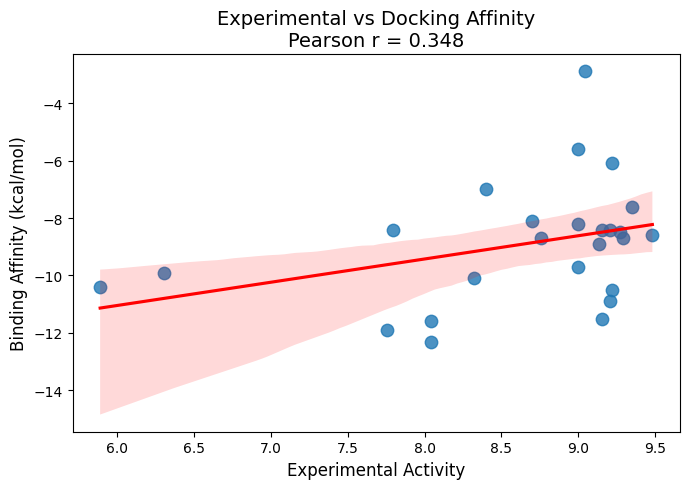

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Pearson Correlation
r, p = pearsonr(df['Actual'], df['Binding Affinity (kcal/mol)'])

# Plot
plt.figure(figsize=(7,5))

sns.regplot(
    x=df['Actual'],
    y=df['Binding Affinity (kcal/mol)'],
    scatter_kws={'s':80},
    line_kws={'color':'red'}
)

plt.title(f'Experimental vs Docking Affinity\nPearson r = {r:.3f}', fontsize=14)
plt.xlabel("Experimental Activity", fontsize=12)
plt.ylabel("Binding Affinity (kcal/mol)", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr

rho1, p1 = spearmanr(df['Actual'], df['Binding Affinity (kcal/mol)'])
rho2, p2 = spearmanr(df['Predicted_DNN'], df['Binding Affinity (kcal/mol)'])

print(f"Spearman Rank Correlation (Experimental vs Docking): {rho1:.3f}")
print(f"Spearman Rank Correlation (Predicted vs Docking): {rho2:.3f}")

Spearman Rank Correlation (Experimental vs Docking): 0.315
Spearman Rank Correlation (Predicted vs Docking): -0.251


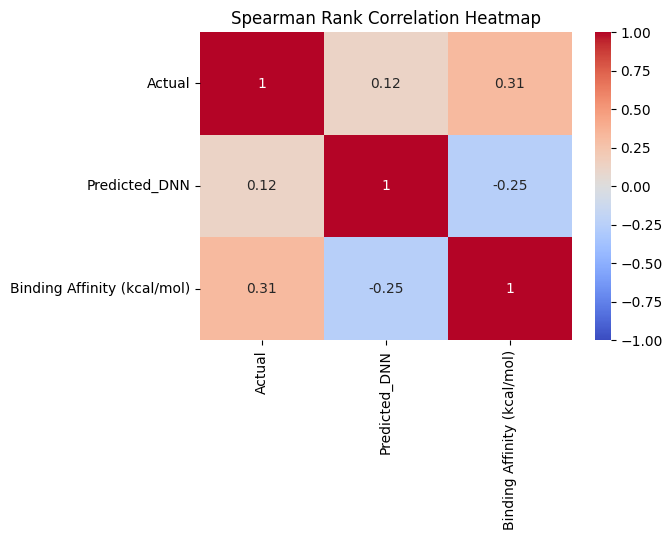

In [ ]:
rank_corr = df[['Actual','Predicted_DNN','Binding Affinity (kcal/mol)']].corr(method='spearman')

plt.figure(figsize=(6,4))

sns.heatmap(
    rank_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Spearman Rank Correlation Heatmap")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Normalize values
df[['Pred_scaled','Dock_scaled']] = scaler.fit_transform(
    df[['Predicted_DNN','Binding Affinity (kcal/mol)']]
)

# Consensus score
df['Consensus Score'] = df['Pred_scaled'] - df['Dock_scaled']

# Sort
consensus_df = df.sort_values(
    by='Consensus Score',
    ascending=False
)

print(consensus_df[['CHEMBL ID',
                    'Actual',
                    'Predicted_DNN',
                    'Binding Affinity (kcal/mol)',
                    'Consensus Score']])

        CHEMBL ID    Actual  Predicted_DNN  Binding Affinity (kcal/mol)  \
0   CHEMBL5286535  9.204815       9.876912                        -10.9   
1   CHEMBL4868952  8.040959       9.246370                        -11.6   
6   CHEMBL4564324  7.754487       9.044613                        -11.9   
5   CHEMBL2031143  9.154902       9.073134                        -11.5   
21  CHEMBL2177920  8.041436       8.756458                        -12.3   
15  CHEMBL4577527  5.889410       8.820567                        -10.4   
17  CHEMBL3394049  9.221849       8.789471                        -10.5   
9   CHEMBL3667413  9.131356       8.951748                         -8.9   
22   CHEMBL381826  8.318759       8.753265                        -10.1   
11  CHEMBL5891177  8.759451       8.910199                         -8.7   
12  CHEMBL6045555  9.481486       8.905582                         -8.6   
23   CHEMBL231862  9.000000       8.752037                         -9.7   
28   CHEMBL234762  6.3053

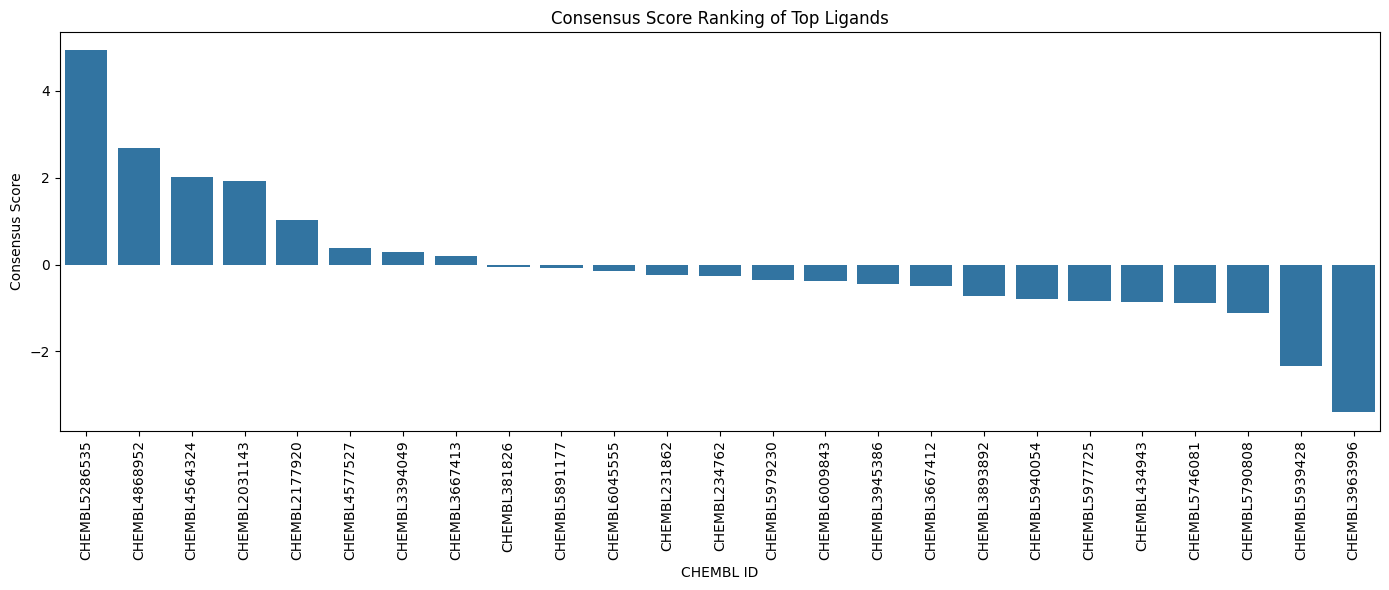

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    x='CHEMBL ID',
    y='Consensus Score',
    data=consensus_df
)

plt.xticks(rotation=90)

plt.title("Consensus Score Ranking of Top Ligands")

plt.tight_layout()

plt.show()